In [1]:
import math
import pioneer

In [2]:
X = pioneer.Variable("x", dim=2)
U = pioneer.Variable("u", dim=1)

In [3]:
square = pioneer.Square(X, [0.0, 0.0], 1.0, 1.0)

point_sampler = pioneer.RandomUniformSampler(square, 10000)
points_sampler_boundary = pioneer.RandomUniformSampler(square.boundary, 5000)

In [4]:
model = pioneer.algorithms.FCN(
    in_neurons=X,
    hidden_neurons=25,
    out_neurons=U,
    n_hidden_layers=4,
    activation=pioneer.building_blocks.Tanh,
)

In [5]:
def residual_fun(u: U, x: X):  # type: ignore
    return u.laplacian(x) + 4*math.pi**2*u

constraint = pioneer.PINNConstraint(residual_fun, name="PINNConstraint")
pde_graph = pioneer.PINNPipeline(point_sampler, [model], constraint)

In [6]:
def boundary_residual_fun(u: U, x: X):  # type: ignore
    cos_1 = pioneer.building_blocks.Cos()(2*math.pi*x[:, :1])
    cos_2 = pioneer.building_blocks.Cos()(2*math.pi*x[:, 1:])
    return u - (cos_1 + cos_2)

boundary_constraint = pioneer.constraints.PINNConstraint(
    boundary_residual_fun, name="BoundaryConstraint", weight=1000.0
)
boundary_graph = pioneer.PINNPipeline(points_sampler_boundary, [model], boundary_constraint)

In [7]:
adam_phase = pioneer.optim.OptimizationPhase(
    optimizer=pioneer.optim.Adam(),
    lr=0.001,
    max_iterations=5000,
)

lbfgs_phase = pioneer.optim.OptimizationPhase(
    optimizer=pioneer.optim.LBFGS(),
    lr=0.1,
    max_iterations=100,
    optimizer_args={"max_eval": 10},
)

trainer = pioneer.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase, lbfgs_phase],
    graphs=[boundary_graph, pde_graph],
    training_objectives=[boundary_constraint, constraint],
    device="cuda:0",
)

trainer.run()

/home/tomfre/miniconda3/envs/PIONEER/lib/python3.10/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
Optimization Phase 2: 100%|██████████| 100/100 [00:15<00:00,  6.26it/s, loss=0.274]


In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

model.to("cpu")

mesh_square = square.create_mesh(0.05)
coords = mesh_square.mesh.vertices
model_out = model(torch.tensor(coords)).detach().numpy()
expected_out = np.cos(2*math.pi*coords[:, :1]) + np.cos(2*math.pi*coords[:, 1:])
error = np.abs(model_out - expected_out)


/home/tomfre/Desktop/pioneer-backend/src/pioneer/geometries/discrete/mesh.py:116: RuntimeWarning: invalid value encountered in divide
  self.boundary_normals_at_vertex /= np.linalg.norm(


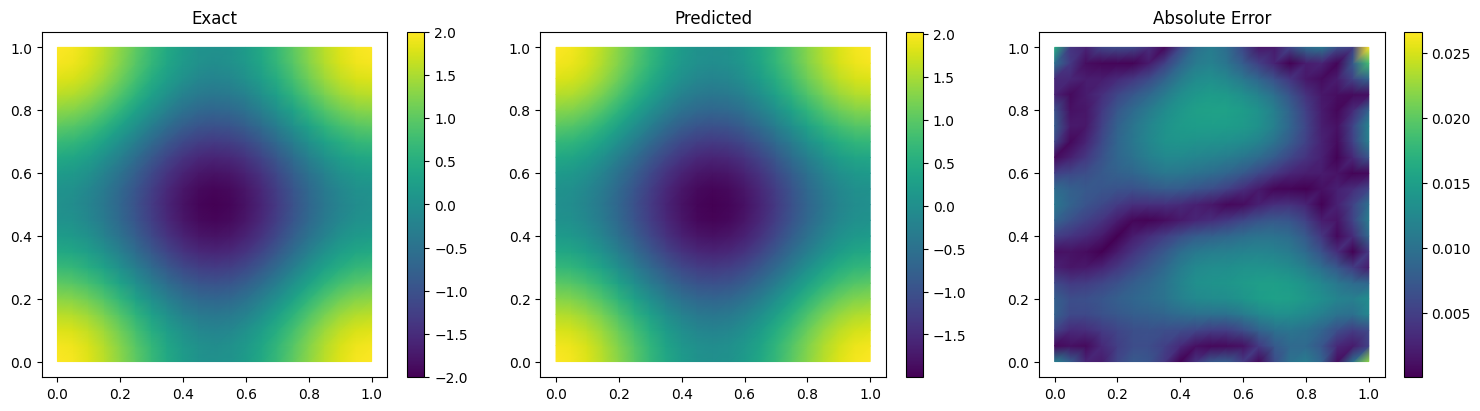

In [9]:
expected_out = expected_out.ravel()
model_out = model_out.ravel()
error = error.ravel()

triang = mtri.Triangulation(
    coords[:, 0],
    coords[:, 1],
    triangles=mesh_square.mesh.cells,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# Exact solution
im0 = axes[0].tripcolor(
    triang,
    expected_out,
    shading="gouraud",
)
axes[0].set_title("Exact")
fig.colorbar(im0, ax=axes[0])

# PINN solution
im1 = axes[1].tripcolor(
    triang,
    model_out,
    shading="gouraud",
)
axes[1].set_title("Predicted")
fig.colorbar(im1, ax=axes[1])

# Error
im2 = axes[2].tripcolor(
    triang,
    error,
    shading="gouraud",
)
axes[2].set_title("Absolute Error")
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_aspect("equal")

plt.show()